# Машинное обучение
# Задание 1. Ridge-регрессия

Дата выдачи: 07.09.2026

#### Шаг 1. Скачайте датасет, откройте его и выведите таблицу на экран

In [25]:
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.typing import NDArray


def load_data(path: str | Path) -> pd.DataFrame:
    return pd.read_csv(path)


df = load_data("apartment_dataset.csv")
df.head(10)

,apartment id,rooms,total area,floor,complex rating,price
0,1,2,60.8,9,4.2,11.54
1,2,4,102.5,17,4.6,20.22
2,3,3,75.7,17,4.9,15.74
3,4,2,66.0,20,4.7,14.10
4,5,1,39.7,16,3.6,6.71
5,6,1,30.1,25,4.0,6.85
6,7,1,31.6,22,3.4,5.53
7,8,3,87.3,13,4.9,17.97
8,9,2,48.1,19,4.3,10.10
9,10,3,75.7,17,3.6,12.80


#### Шаг 2. Разделите выборку на тренировочную, валидационную и тестовую:
* в тренировочной: 100 первых квартир;
* в валидационной: 50 следующих квартир;
* в тестовой: 50 последних квартир.
* в каждой выборке матрица X — это столбцы `rooms`, `total area`, `floor`, `complex rating`, а y — столбец `price`.

Названия: `X_train`, `y_train`, `X_val`, `y_val`, `X_test`, `y_test`.

In [26]:
def split_data(
    df: pd.DataFrame,
    features: list[str],
    target: str,
    train_size: int = 100,
    val_size: int = 50,
) -> tuple[
    NDArray[np.float64],
    NDArray[np.float64],
    NDArray[np.float64],
    NDArray[np.float64],
    NDArray[np.float64],
    NDArray[np.float64],
]:
    X = df[features].to_numpy(dtype=np.float64)
    y = df[target].to_numpy(dtype=np.float64)
    return (
        X[:train_size],
        y[:train_size],
        X[train_size : train_size + val_size],
        y[train_size : train_size + val_size],
        X[train_size + val_size :],
        y[train_size + val_size :],
    )


features = ["rooms", "total area", "floor", "complex rating"]
target = "price"

X_train, y_train, X_val, y_val, X_test, y_test = split_data(df, features, target)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (100, 4) (100,)
Val:   (50, 4) (50,)
Test:  (50, 4) (50,)


#### Шаг 3. Импортируйте инструменты для Ridge-регрессии

In [27]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler


def scale_features(
    X_train: NDArray[np.float64],
    X_val: NDArray[np.float64],
    X_test: NDArray[np.float64],
) -> tuple[NDArray[np.float64], NDArray[np.float64], NDArray[np.float64], StandardScaler]:
    scaler = StandardScaler()
    return (
        scaler.fit_transform(X_train),  # type: ignore
        scaler.transform(X_val),
        scaler.transform(X_test),
        scaler,
    )


def fit_ridge(
    X_train: NDArray[np.float64],
    y_train: NDArray[np.float64],
    *,
    alpha: float = 1.0,
    solver: Literal["sparse_cg"] = "sparse_cg",
) -> Ridge:
    model = Ridge(alpha=alpha, solver=solver)
    model.fit(X_train, y_train)
    return model


def compute_errors(y_true: NDArray[np.float64], y_pred: NDArray[np.float64]) -> dict[str, float]:
    err = y_true - y_pred
    sse = float(np.sum(err**2))
    mse = float(np.mean(err**2))
    return {"sse": sse, "mse": mse, "rmse": float(np.sqrt(mse))}

#### Шаг 4. Обучите модель линейной регрессии на тренировочной выборке с помощью `Ridge` и `solver='sparse_cg'`; оцените ошибку SSE.

In [28]:
X_train_s, X_val_s, X_test_s, scaler = scale_features(X_train, X_val, X_test)

ridge = fit_ridge(X_train_s, y_train, alpha=1.0)

print("Коэффициенты:", ridge.coef_)
print("Свободный член:", ridge.intercept_)

train_metrics = compute_errors(y_train, ridge.predict(X_train_s))
val_metrics = compute_errors(y_val, ridge.predict(X_val_s))
print("SSE на train:", train_metrics["sse"])
print("RMSE train:", train_metrics["rmse"])
print("RMSE val:  ", val_metrics["rmse"])

Коэффициенты: [0.76685802 3.17502835 0.2776087  1.0628486 ]
Свободный член: 11.141499999999999
SSE на train: 15.45233883178113
RMSE train: 0.39309463023273583
RMSE val:   0.4352949893531397


#### Шаг 5. Реализуйте обучение вручную градиентным спуском и постройте графики SSE, MSE, RMSE для train и val

Алгоритм должен останавливаться, когда либо модуль разности функции потерь между итерациями меньше `epsilon`, либо достигнуто максимальное число итераций.

In [29]:
def add_bias(X: NDArray[np.float64]) -> NDArray[np.float64]:
    return np.c_[np.ones(X.shape[0]), X]


def train_gradient_descent(
    X_train: NDArray[np.float64],
    y_train: NDArray[np.float64],
    X_val: NDArray[np.float64],
    y_val: NDArray[np.float64],
    *,
    alpha: float = 1.0,
    lr: float = 1e-4,
    max_iter: int = 10_000,
    epsilon: float = 1e-3,
) -> tuple[NDArray[np.float64], dict[str, list[float]], dict[str, list[float]]]:
    X_train_b = add_bias(X_train)
    X_val_b = add_bias(X_val)

    weights = np.zeros(X_train_b.shape[1], dtype=np.float64)

    train_hist: dict[str, list[float]] = {"sse": [], "mse": [], "rmse": []}
    val_hist: dict[str, list[float]] = {"sse": [], "mse": [], "rmse": []}

    prev_loss = float("inf")

    for it in range(max_iter):
        pred_train = X_train_b @ weights
        pred_val = X_val_b @ weights

        train_metrics = compute_errors(y_train, pred_train)
        val_metrics = compute_errors(y_val, pred_val)

        train_hist["sse"].append(train_metrics["sse"])
        train_hist["mse"].append(train_metrics["mse"])
        train_hist["rmse"].append(train_metrics["rmse"])
        val_hist["sse"].append(val_metrics["sse"])
        val_hist["mse"].append(val_metrics["mse"])
        val_hist["rmse"].append(val_metrics["rmse"])

        loss = train_metrics["sse"] + alpha * float(np.sum(weights[1:] ** 2))

        if abs(prev_loss - loss) < epsilon:
            print(f"Остановка на итерации {it}: |J_t - J_{{t-1}}| < {epsilon}")
            break
        prev_loss = loss

        err_train = y_train - pred_train
        grad = -2 * X_train_b.T @ err_train
        grad[1:] += 2 * alpha * weights[1:]
        weights -= lr * grad
    else:
        print(f"Достигнуто максимальное число итераций ({max_iter})")

    return weights, train_hist, val_hist


w, train_hist, val_hist = train_gradient_descent(
    X_train_s,
    y_train,
    X_val_s,
    y_val,
    alpha=1.0,
    lr=0.0001,
    max_iter=10_000,
    epsilon=0.001,
)

print("Итоговые веса:", w)
print("Итоговый RMSE train:", train_hist["rmse"][-1])
print("Итоговый RMSE val:  ", val_hist["rmse"][-1])

Остановка на итерации 1842: |J_t - J_{t-1}| < 0.001
Итоговые веса: [11.1415      1.05137756  2.89039834  0.28091952  1.05958034]
Итоговый RMSE train: 0.4159595786586982
Итоговый RMSE val:   0.4669347987303437


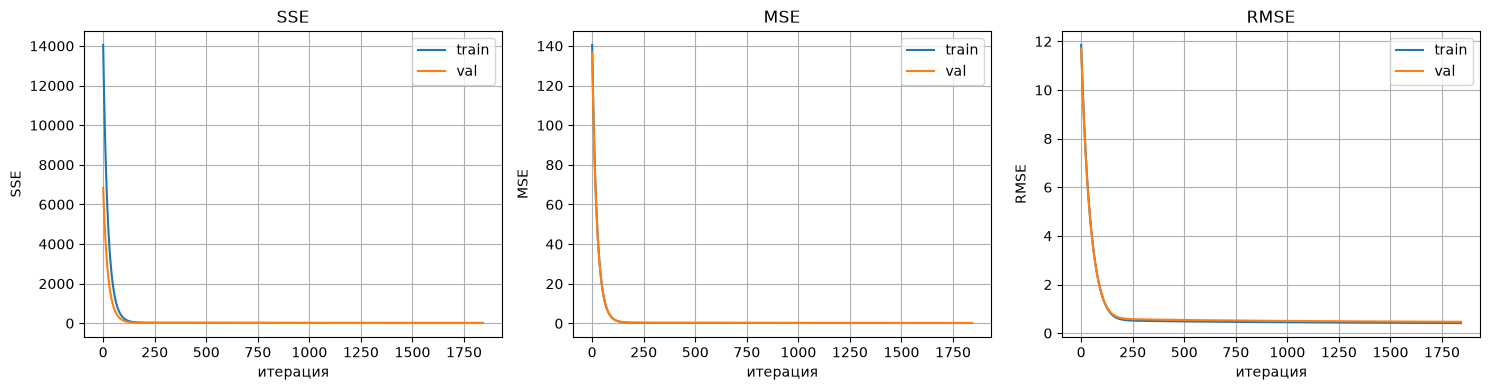

In [30]:
def plot_errors(
    train_hist: dict[str, list[float]],
    val_hist: dict[str, list[float]],
) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # type: ignore

    for ax, metric in zip(axes, ["sse", "mse", "rmse"], strict=True):
        ax.plot(train_hist[metric], label="train")
        ax.plot(val_hist[metric], label="val")
        ax.set_title(metric.upper())
        ax.set_xlabel("итерация")
        ax.set_ylabel(metric.upper())
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()  # type: ignore


plot_errors(train_hist, val_hist)

#### Ответьте на вопрос, какую модель Вы получили: обученную, переобученную или недообученную?

* если на графиках все три ошибки для обеих выборок падают — модель обучилась хорошо;
* если ошибки на train падают, а на val с какого-то момента растут — модель переобучилась;
* если обе ошибки остаются высокими — модель недообучилась.

**Ответ:** модель обучилась хорошо. На всех трёх графиках ошибки на train и val убывают и затем стабилизируются, разрыв между ними невелик. Переобучения не наблюдается.

#### Шаг 6. Примените модель на тестовой выборке, чтобы предсказать цены квартир

1. Найдите `y_predict`.
2. Для каждой квартиры из test выведите id, предсказанную цену, настоящую цену и разницу.
3. Сохраните получившуюся таблицу в CSV.

In [31]:
def make_predictions(
    df: pd.DataFrame,
    X_test: NDArray[np.float64],
    y_test: NDArray[np.float64],
    weights: NDArray[np.float64],
    id_col: str = "apartment id",
) -> pd.DataFrame:
    y_pred_test = add_bias(X_test) @ weights
    results = pd.DataFrame(
        {
            "apartment id": df[id_col].iloc[-len(y_test) :].to_numpy(),
            "predicted price": y_pred_test,
            "real price": y_test,
            "difference": y_pred_test - y_test,
        }
    )
    return results.round(2)


results = make_predictions(df, X_test_s, y_test, w)
results.to_csv("test_predictions.csv", index=False)
results.head(10)

,apartment id,predicted price,real price,difference
0,151,20.69,21.54,-0.85
1,152,9.74,9.73,0.01
2,153,7.56,7.74,-0.18
3,154,10.75,10.15,0.60
4,155,17.81,17.27,0.54
5,156,8.88,8.23,0.65
6,157,8.74,8.52,0.22
7,158,14.69,14.95,-0.26
8,159,8.23,8.16,0.07
9,160,14.86,14.95,-0.09


In [32]:
test_metrics = compute_errors(y_test, add_bias(X_test_s) @ w)
print(f"Test SSE:  {test_metrics['sse']:.2f}")
print(f"Test MSE:  {test_metrics['mse']:.2f}")
print(f"Test RMSE: {test_metrics['rmse']:.2f}")

Test SSE:  15.72
Test MSE:  0.31
Test RMSE: 0.56


### Поздравляю! Вы обучили модель и уже сделали первый шаг в машинном обучении! Молодцы!